In [69]:
import os
import re
from pathlib import Path

import geopandas as gpd
import ipywidgets as widgets
import lasio as ls
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.spatial import cKDTree


In [70]:
# ---------------------------------------------------------------------
# 0) Paths and input files
# ---------------------------------------------------------------------
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

csv_path = Path(
    "./outputs/merged_inversion_results/merged_iteration_14_resistivity_wide.csv"
)
if not csv_path.exists():
    raise FileNotFoundError(f"CSV not found: {csv_path}")

# well_data_dir = Path("data/well_data")
well_data_dir = Path("data/aer/well")
# water_well_shp = well_data_dir / "WaterWell_HQ_LAS/WaterWell_HQ_LAS/Shapefile/WWLAS_CLC_HQ.shp"
# coal_hole_shp = well_data_dir / "CoalHoles_HQ_LAS/CoalHoles_HQ_LAS/ShapeFile/CoalHole_CLC_HQ.shp"
water_well_shp = well_data_dir / "WaterWell_HQ_LAS/Shapefile/WWLAS_CLC_HQ.shp"
coal_hole_shp = well_data_dir / "CoalHoles_HQ_LAS/ShapeFile/CoalHole_CLC_HQ.shp"
print(water_well_shp)
if not water_well_shp.exists() or not coal_hole_shp.exists():
    raise FileNotFoundError("Well shapefile(s) not found under data/well_data")


data/aer/well/WaterWell_HQ_LAS/Shapefile/WWLAS_CLC_HQ.shp


In [71]:
# ---------------------------------------------------------------------
# 1) Load iteration-14 inversion CSV
# ---------------------------------------------------------------------
iter14_df = pd.read_csv(csv_path)

# Numeric cleanup
for col in ["x_wgs84", "y_wgs84", "distance", "dtm", "bheight"]:
    if col in iter14_df.columns:
        iter14_df[col] = pd.to_numeric(
            iter14_df[col], errors="coerce"
        )  # "coerce" set invalid values to NaN.
if "Line" in iter14_df.columns:
    iter14_df["Line"] = iter14_df["Line"].astype(str)

rho_cols = [c for c in iter14_df.columns if c.startswith("rho_") and c.endswith("m")]
if len(rho_cols) == 0:
    raise ValueError(
        "No resistivity columns found in CSV (expected rho_XX.XXm columns)"
    )


# Get depth values from column names with "regex".
def parse_depth_from_col(col_name):
    # (...) is a capturing group (create a groups).
    # [0-9]+ matches any digit from 0 to 9, one or more.
    # (?:...) is a non-capturing group (don't create a group).
    # \.[0-9]+ matches with . followed by one or more digits.
    # ()? makes the previous group optional (0 or 1 times).
    match = re.match(r"rho_([0-9]+(?:\.[0-9]+)?)m", col_name)
    return float(match.group(1)) if match else np.nan


depth_values = np.array([parse_depth_from_col(c) for c in rho_cols], dtype=float)
sort_idx = np.argsort(depth_values)
rho_cols = [rho_cols[i] for i in sort_idx]
depth_values = depth_values[sort_idx]


In [72]:
# Capture valid x-/y- coordinates.
xy = iter14_df[["x_wgs84", "y_wgs84"]].to_numpy(dtype=float)
xy_valid_mask = np.isfinite(xy).all(axis=1)
if not np.any(xy_valid_mask):
    raise ValueError("No valid x_wgs84 / y_wgs84 values found in CSV")


In [73]:
# Create a KDTree for fast nearest-neighbor search of valid x-/y- coordinates.
iter14_valid = iter14_df.loc[xy_valid_mask].reset_index(drop=True)
xy_valid = iter14_valid[["x_wgs84", "y_wgs84"]].to_numpy(dtype=float)
model_tree = cKDTree(xy_valid)

In [74]:
# Robust color range for map
all_rho = iter14_valid[rho_cols].to_numpy(dtype=float)
valid_rho = all_rho[np.isfinite(all_rho) & (all_rho > 0)]

In [75]:
gpd.read_file("./data/aer/well/WaterWell_HQ_LAS/Tables/WWLAS_CLC_HQ_collar.dbf").head(1)

,LAS_FI_NAM,GIC_W_ID,LONG_NAD83,LAT_NAD83,UTM83_Z,E_UTM83,N_UTM83,E_10TM83,N_10TM83,EL_DEM15_M,DLS_LOC,CURVE_TYPE,SHORTNAME,PUBLISHER,SHORTNAME_
0,153840-a,153840.0,113.69356,50.17612,12.0,307679.0,5561685.0,593284.0,5559029.0,1062.0,151301428M4,DEPTH BELOW REFERENCE; RESISTIVITY; GAMMA RAY,DEPT; RES; GR,Alberta Geological Survey,3.0


In [76]:
gpd.read_file("./data/aer/well/WaterWell_HQ_LAS/Shapefile/WWLAS_CLC_HQ.shp").head(1)

,LAS_FI_NAM,GIC_W_ID,LONG_NAD83,LAT_NAD83,UTM83_Z,E_UTM83,N_UTM83,E_10TM83,N_10TM83,EL_DEM15_M,DLS_LOC,CURVE_TYPE,SHORTNAME,PUBLISHER,SHORTNAME_,geometry
0,153840-a,153840.0,113.69356,50.17612,12.0,307679.0,5561685.0,593284.0,5559029.0,1062.0,151301428M4,DEPTH BELOW REFERENCE; RESISTIVITY; GAMMA RAY,DEPT; RES; GR,Alberta Geological Survey,3.0,POINT Z (593284 5559029 1062)


In [77]:
a = ls.read(well_data_dir / "WaterWell_HQ_LAS/LAS_Files/153847-a.las")
a.df().head()

,RES,GR
DEPT,,
0.25,NaN,80.5073
0.50,NaN,80.5280
0.75,NaN,80.5798
1.00,NaN,80.6315
1.25,NaN,80.6936


In [78]:
# ---------------------------------------------------------------------
# 2) Load wells and build a single well table (UTM12 or NAD83)
# ---------------------------------------------------------------------
ww_gdf = gpd.read_file(water_well_shp).to_crs(epsg=26912)
ch_gdf = gpd.read_file(coal_hole_shp).to_crs(epsg=26912)


# Extract candidate well names from a given row.
def pick_name(row, candidates):
    for col in candidates:
        if col in row.index and not pd.isna(row[col]):
            text = str(row[col]).strip()
            if text != "":
                return text
    return None


# Extract meta data of well. (well type, well name, x, y)

well_records = []

# For Water well.
for _, row in ww_gdf.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    # Extract well name defined with priority: LAS_FI_NAM > Name > SHORTNAME from a given row.
    name = pick_name(row, ["LAS_FI_NAM", "Name", "SHORTNAME"])
    if name is None:
        continue
    well_records.append(
        {
            "well_type": "WaterWell",
            "well_name": name,
            "x": float(row.geometry.x),
            "y": float(row.geometry.y),
        }
    )

# For Coal hole.
for _, row in ch_gdf.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    name = pick_name(row, ["Name", "LAS_FI_NAM", "Name_1"])
    if name is None:
        continue
    well_records.append(
        {
            "well_type": "CoalHole",
            "well_name": name,
            "x": float(row.geometry.x),
            "y": float(row.geometry.y),
        }
    )

well_df = pd.DataFrame(well_records)
if well_df.empty:
    raise ValueError("No valid wells were found in shapefiles")

well_df["well_id"] = well_df["well_type"] + " | " + well_df["well_name"]

In [79]:
well_df.head(2)

,well_type,well_name,x,y,well_id
0,WaterWell,153840-a,307835.034573,5.563906e+06,WaterWell | 153840-a
1,WaterWell,153842-a,307865.241639,5.563872e+06,WaterWell | 153842-a


In [80]:
# Nearest inversion model for each well
well_xy = well_df[["x", "y"]].to_numpy(dtype=float)
nearest_dist, nearest_model_idx = model_tree.query(
    well_xy
)  # nearest_dist: distance to nearest model, nearest_model_idx: index of nearest model in iter14_valid
well_df["nearest_model_idx"] = nearest_model_idx
well_df["nearest_model_dist_m"] = nearest_dist
well_df["well_name_key"] = well_df["well_name"].astype(str).str.strip().str.upper()

In [81]:
# I can see the closest inversion model location for each well in the well_df table.
well_df.head(2)

,well_type,well_name,x,y,well_id,nearest_model_idx,nearest_model_dist_m,well_name_key
0,WaterWell,153840-a,307835.034573,5.563906e+06,WaterWell | 153840-a,508184,173.407376,153840-A
1,WaterWell,153842-a,307865.241639,5.563872e+06,WaterWell | 153842-a,508185,192.408834,153842-A


In [107]:
# ---------------------------------------------------------------------
# 3) Optional well log and lithology readers (overlay in right panel)
# ---------------------------------------------------------------------
water_lith_path = well_data_dir / "WaterWell_HQ_LAS/Tables/WWLAS_CLC_HQ_lithology.DBF"
water_collar_path = well_data_dir / "WaterWell_HQ_LAS/Tables/WWLAS_CLC_HQ_collar.dbf"
coal_lith_path = well_data_dir / "CoalHoles_HQ_LAS/Tables/CoalHole_CLC_HQ_Lithology.txt"

lithology_columns = [
    "well_type",
    "well_name",
    "top_m",
    "bottom_m",
    "display_label",
]

In [83]:
gpd.read_file(water_collar_path).head(3)

,LAS_FI_NAM,GIC_W_ID,LONG_NAD83,LAT_NAD83,UTM83_Z,E_UTM83,N_UTM83,E_10TM83,N_10TM83,EL_DEM15_M,DLS_LOC,CURVE_TYPE,SHORTNAME,PUBLISHER,SHORTNAME_
0,153840-a,153840.0,113.69356,50.17612,12.0,307679.0,5561685.0,593284.0,5559029.0,1062.0,151301428M4,DEPTH BELOW REFERENCE; RESISTIVITY; GAMMA RAY,DEPT; RES; GR,Alberta Geological Survey,3.0
1,153842-a,153842.0,113.69313,50.17582,12.0,307708.0,5561650.0,593316.0,5558996.0,1060.0,151301428M4,DEPTH BELOW REFERENCE; RESISTIVITY; GAMMA RAY,DEPT; RES; GR,Alberta Geological Survey,3.0
2,153926-a,153926.0,112.58949,51.19252,12.0,388931.0,5672434.0,668432.0,5673995.0,945.0,090402619M4,DEPTH BELOW REFERENCE; RESISTIVITY; GAMMA RAY,DEPT; RES; GR,Alberta Geological Survey,3.0


In [84]:
gpd.read_file(water_lith_path).head(3)

,GIC_WELL_I,WELL_REPOR,FINALFROM,FINALTO,WATER_BEAR,COLOUR,DESCRIPTIO,MATERIAL,FINALFROM_,FINALTO_M
0,111800.0,111800.0,0.0,34.0,False,Brown,NaN,Clay,0.0000,10.3632
1,111800.0,111800.0,34.0,74.0,False,Blue,NaN,Clay,10.3632,22.5552
2,111800.0,111800.0,74.0,117.0,False,Blue,NaN,Clay,22.5552,35.6616


In [85]:
# Water well collar data (well name and ID)
water_collar_df = gpd.read_file(water_collar_path)[
    ["LAS_FI_NAM", "GIC_W_ID"]
].copy()  # For well name
water_collar_df["GIC_W_ID"] = pd.to_numeric(
    water_collar_df["GIC_W_ID"], errors="coerce"
)
water_collar_df["well_name"] = water_collar_df["LAS_FI_NAM"].astype(str).str.strip()

In [86]:
water_collar_df.head(2)

,LAS_FI_NAM,GIC_W_ID,well_name
0,153840-a,153840.0,153840-a
1,153842-a,153842.0,153842-a


In [108]:
# Water litho data
water_lith_df = gpd.read_file(water_lith_path).copy()

# Convert numeric data.
water_lith_df["GIC_WELL_I"] = pd.to_numeric(
    water_lith_df["GIC_WELL_I"], errors="coerce"
)
print(water_lith_df.head(2))

# Merge litho data with collar data to get well names.
water_lith_df = water_lith_df.merge(
    water_collar_df[["GIC_W_ID", "well_name"]],
    left_on="GIC_WELL_I",
    right_on="GIC_W_ID",
    how="left",
)
water_lith_df["top_m"] = pd.to_numeric(water_lith_df["FINALFROM_"], errors="coerce")
water_lith_df["bottom_m"] = pd.to_numeric(water_lith_df["FINALTO_M"], errors="coerce")
water_lith_df["raw_lithology"] = (
    water_lith_df["MATERIAL"].fillna("Unknown").astype(str).str.strip()
)

   GIC_WELL_I  WELL_REPOR  FINALFROM  FINALTO  WATER_BEAR COLOUR DESCRIPTIO  \
0    111800.0    111800.0        0.0     34.0       False  Brown        NaN   
1    111800.0    111800.0       34.0     74.0       False   Blue        NaN   

  MATERIAL  FINALFROM_  FINALTO_M  
0     Clay      0.0000    10.3632  
1     Clay     10.3632    22.5552  


In [109]:
from tools.class_litho import classify_broad_lithology

water_lith_df["display_label"] = (
    water_lith_df["MATERIAL"].fillna("Unknown").astype(str).str.strip().apply(classify_broad_lithology)
)

In [110]:
water_lith_df["well_type"] = "WaterWell"
water_lith_df = water_lith_df[lithology_columns].copy()

In [90]:
# I can see
water_lith_df.head(10)

,well_type,well_name,top_m,bottom_m,display_label,color_hint
0,WaterWell,111800-a,0.0000,10.3632,Clay,Brown
1,WaterWell,111800-a,10.3632,22.5552,Clay,Blue
2,WaterWell,111800-a,22.5552,35.6616,Clay,Blue
3,WaterWell,111800-a,35.6616,40.2336,Shale/Mudstone,Blue
4,WaterWell,111800-a,40.2336,40.8432,Silt/Siltstone,NaN
5,WaterWell,111800-a,40.8432,50.2920,Shale/Mudstone,NaN
6,WaterWell,111800-a,50.2920,58.5216,Sand/Sandstone,NaN
7,WaterWell,111800-a,58.5216,70.7136,Sand/Sandstone,NaN
8,WaterWell,111800-a,70.7136,72.2376,Shale/Mudstone,Brown
9,WaterWell,111858-a,0.0000,24.9936,Clay,Brown


In [91]:
def make_well_lookup_key(well_name, well_type):
    return f"{well_type}|{str(well_name).strip().upper()}"


def load_well_lithology(well_name, well_type):
    return lithology_by_well.get(make_well_lookup_key(well_name, well_type))


def lithology_facecolor(display_label, color_hint=None):
    return to_rgba(lithology_color_map.get(display_label, (0.7, 0.7, 0.7)), alpha=0.45)


def load_well_las(well_name, well_type):
    if well_type == "WaterWell":
        las_path = Path(well_data_dir / f"WaterWell_HQ_LAS/LAS_Files/{well_name}.las")
    else:
        las_path = Path(
            well_data_dir / f"CoalHoles_HQ_LAS/LAS_Files/Litholog_{well_name}.las"
        )
        if not las_path.exists():
            las_path = Path(
                well_data_dir / f"CoalHoles_HQ_LAS/LAS_Files/Litholog_{well_name}_A.las"
            )

    if not las_path.exists():
        return None, None

    las = ls.read(las_path)
    df_las = las.df()
    depth = np.asarray(df_las.index.values, dtype=float)

    units = las.index_unit
    if units is None and len(las.curves) > 0:
        units = las.curves[0].unit
    if units is not None:
        units = str(units).upper()
        if "FT" in units or "FEET" in units:
            depth = depth * 0.3048

    res = None
    for col in ["RES", "RES1", "RES2", "CILD"]:
        if col in df_las.columns:
            values = np.asarray(df_las[col].values, dtype=float)
            if col == "CILD":
                values = 1000.0 / (values + 1e-6)
            res = values
            break

    if res is None:
        return None, None

    mask = (
        np.isfinite(depth) & np.isfinite(res) & (depth >= 0) & (res > 0) & (res < 1e5)
    )
    if not np.any(mask):
        return None, None
    return depth[mask], res[mask]

In [111]:
coal_source_columns = [
    "well_name",
    "record_id",
    "from_ft",
    "to_ft",
    "depth_unit",
    "top_m",
    "bottom_m",
    "top_m_dup",
    "bottom_m_dup",
    "lith_primary",
    "lith_secondary",
    "rock_color",
    "description",
    "extra",
]
coal_input_columns = [
    "well_name",
    "top_m",
    "bottom_m",
    "lith_primary",
    "lith_secondary",
    "description",
]

coal_lith_df = pd.read_csv(
    coal_lith_path,
    header=None,
    names=coal_source_columns,
    usecols=coal_input_columns,
)
coal_lith_df["well_name"] = coal_lith_df["well_name"].astype(str).str.strip()
coal_lith_df["top_m"] = pd.to_numeric(coal_lith_df["top_m"], errors="coerce")
coal_lith_df["bottom_m"] = pd.to_numeric(coal_lith_df["bottom_m"], errors="coerce")
coal_lith_df["raw_lithology"] = coal_lith_df.apply(
    lambda row: " / ".join(
        value
        for value in [
            str(row["lith_primary"]).strip(),
            str(row["lith_secondary"]).strip(),
            str(row["description"]).strip(),
        ]
        if value and value.lower() != "nan"
    ) or "Unknown",
    axis=1,
)
coal_lith_df["display_label"] = coal_lith_df["raw_lithology"].apply(classify_broad_lithology)
coal_lith_df["well_type"] = "CoalHole"
coal_lith_df = coal_lith_df[lithology_columns].copy()

In [93]:
water_collar_df.head(2)

,LAS_FI_NAM,GIC_W_ID,well_name
0,153840-a,153840.0,153840-a
1,153842-a,153842.0,153842-a


In [94]:
coal_lith_df.head(2)

,well_type,well_name,top_m,bottom_m,display_label,color_hint
0,CoalHole,TH28-76,146.30,149.35,Silt/Siltstone,NaN
1,CoalHole,TH28-76,149.35,150.88,Silt/Siltstone,NaN


In [112]:
lithology_df = pd.concat([water_lith_df, coal_lith_df], ignore_index=True)
lithology_df = lithology_df.loc[
    lithology_df["well_name"].notna()
    & np.isfinite(lithology_df["top_m"])
    & np.isfinite(lithology_df["bottom_m"])
    & (lithology_df["bottom_m"] > lithology_df["top_m"])
].copy()
lithology_df["well_name_key"] = lithology_df["well_name"].astype(str).str.strip().str.upper()
lithology_df["lookup_key"] = lithology_df["well_type"] + "|" + lithology_df["well_name_key"]

lith_palette = plt.get_cmap("tab20").colors
lithology_color_map = {
    label: lith_palette[index % len(lith_palette)]
    for index, label in enumerate(sorted(lithology_df["display_label"].dropna().unique()))
}
lithology_legend_handles = [
    Patch(
        facecolor=to_rgba(lithology_color_map[label], alpha=0.45),
        edgecolor="white",
        linewidth=0.4,
        label=label,
    )
    for label in sorted(lithology_color_map)
]
lithology_by_well = {
    key: group.sort_values(["top_m", "bottom_m"]).reset_index(drop=True)
    for key, group in lithology_df.groupby("lookup_key")
}

lithology_color_table = pd.DataFrame(
    [
        {
            "lithology": label,
            "hex_color": "#{:02x}{:02x}{:02x}".format(
                *(np.array(color[:3]) * 255).round().astype(int)
            ),
        }
        for label, color in sorted(lithology_color_map.items())
    ]
)
lithology_color_table.style.map(
    lambda hex_color: f"background-color: {hex_color}",
    subset=["hex_color"],
)

,lithology,hex_color
0,Bentonite,#1f77b4
1,Carbonaceous,#aec7e8
2,Clay,#ff7f0e
3,Coal,#ffbb78
4,No recovery,#2ca02c
5,Other,#98df8a
6,Sand/Sandstone,#d62728
7,Shale/Mudstone,#ff9896
8,Silt/Siltstone,#9467bd
9,Till/Overburden,#c5b0d5


In [96]:
lithology_by_well

{'CoalHole|TH10-83':    well_type well_name  top_m  bottom_m   display_label color_hint  \
 0   CoalHole   TH10-83   0.00      3.05    Carbonaceous        NaN   
 1   CoalHole   TH10-83   3.05      6.10    Carbonaceous        NaN   
 2   CoalHole   TH10-83   6.10      9.14    Carbonaceous        NaN   
 3   CoalHole   TH10-83   9.14     12.19    Carbonaceous        NaN   
 4   CoalHole   TH10-83  12.19     15.24    Carbonaceous        NaN   
 5   CoalHole   TH10-83  15.24     18.29    Carbonaceous        NaN   
 6   CoalHole   TH10-83  18.29     21.34    Carbonaceous        NaN   
 7   CoalHole   TH10-83  21.34     27.43    Carbonaceous        NaN   
 8   CoalHole   TH10-83  27.43     30.48    Carbonaceous        NaN   
 9   CoalHole   TH10-83  30.48     33.53    Carbonaceous        NaN   
 10  CoalHole   TH10-83  33.53     36.58    Carbonaceous        NaN   
 11  CoalHole   TH10-83  36.58     39.62    Carbonaceous        NaN   
 12  CoalHole   TH10-83  39.62     42.67  Silt/Siltstone 

In [97]:
vmin = 8
vmax = 60

In [98]:
# ---------------------------------------------------------------------
# Click-based point selection + nearby well statistics
# ---------------------------------------------------------------------
# NOTE: click events need an interactive matplotlib backend in notebooks.

search_radius_m = 5_000.0  # 5 km
well_marker_size = 70
selected_well_marker_size = 220
click_marker_size = 90
atem_marker_size = 120


In [99]:
atem_xy = iter14_valid[["x_wgs84", "y_wgs84"]].to_numpy(dtype=float)

case_selector = widgets.Dropdown(
    options=[
        ("All wells", "all"),
        ("With lithology only", "with_lithology_only"),
        ("With resistivity log only", "with_resistivity_only"),
        ("With both", "with_both"),
        ("With neither", "with_neither"),
    ],
    value="all",
    description="Case",
    layout=widgets.Layout(width="280px"),
)

In [100]:
def has_lithology(well_name, well_type):
    lith = load_well_lithology(well_name, well_type)
    return lith is not None and not lith.empty


def has_resistivity_log(well_name, well_type):
    depth, res = load_well_las(well_name, well_type)
    return depth is not None and res is not None and len(depth) > 0 and len(res) > 0

In [101]:
availability_cache = {}


def get_well_availability(well_id, well_name, well_type):
    cached = availability_cache.get(well_id)
    if cached is not None:
        return cached

    result = {
        "has_lithology": has_lithology(well_name, well_type),
        "has_resistivity_log": has_resistivity_log(well_name, well_type),
    }
    result["has_both"] = result["has_lithology"] and result["has_resistivity_log"]
    availability_cache[well_id] = result
    return result

In [102]:
def get_case_mask(case_name):
    if case_name == "all":
        return pd.Series(True, index=well_df.index)

    availability = well_df.apply(
        lambda row: get_well_availability(
            row["well_id"], row["well_name"], row["well_type"]
        ),
        axis=1,
    )

    has_lith = pd.Series(
        [v["has_lithology"] for v in availability], index=well_df.index
    )
    has_res = pd.Series(
        [v["has_resistivity_log"] for v in availability], index=well_df.index
    )

    if case_name == "with_lithology_only":
        return has_lith & ~has_res
    if case_name == "with_resistivity_only":
        return has_res & ~has_lith
    if case_name == "with_both":
        return has_lith & has_res
    if case_name == "with_neither":
        return (~has_lith) & (~has_res)

    return pd.Series(True, index=well_df.index)


def summarize_nearby_wells(center_x, center_y, radius_m, case_name="all"):
    case_mask = get_case_mask(case_name)
    case_wells = well_df.loc[case_mask].copy()

    if case_wells.empty:
        return case_wells, None, None, np.nan

    well_dist_to_center = np.hypot(
        case_wells["x"].to_numpy(dtype=float) - center_x,
        case_wells["y"].to_numpy(dtype=float) - center_y,
    )

    nearby_wells = case_wells.copy()
    nearby_wells["distance_to_click_m"] = well_dist_to_center
    nearby_wells = nearby_wells.loc[
        nearby_wells["distance_to_click_m"] <= radius_m
    ].copy()
    nearby_wells = nearby_wells.sort_values("distance_to_click_m").reset_index(
        drop=True
    )

    if nearby_wells.empty:
        return nearby_wells, None, None, float(np.nanmin(well_dist_to_center))

    avail = [
        get_well_availability(r.well_id, r.well_name, r.well_type)
        for r in nearby_wells.itertuples(index=False)
    ]
    nearby_wells["has_lithology"] = [v["has_lithology"] for v in avail]
    nearby_wells["has_resistivity_log"] = [v["has_resistivity_log"] for v in avail]
    nearby_wells["has_both"] = [v["has_both"] for v in avail]

    summary = pd.DataFrame(
        {
            "metric": [
                "total_wells_within_radius",
                "with_lithology_only",
                "with_resistivity_only",
                "with_both",
                "with_neither",
            ],
            "count": [
                len(nearby_wells),
                int(
                    (
                        nearby_wells["has_lithology"]
                        & ~nearby_wells["has_resistivity_log"]
                    ).sum()
                ),
                int(
                    (
                        nearby_wells["has_resistivity_log"]
                        & ~nearby_wells["has_lithology"]
                    ).sum()
                ),
                int(nearby_wells["has_both"].sum()),
                int(
                    (
                        ~nearby_wells["has_lithology"]
                        & ~nearby_wells["has_resistivity_log"]
                    ).sum()
                ),
            ],
        }
    )

    by_type = (
        nearby_wells.groupby("well_type")[
            ["has_lithology", "has_resistivity_log", "has_both"]
        ]
        .sum()
        .astype(int)
    )
    by_type["total_wells"] = nearby_wells.groupby("well_type").size().astype(int)
    by_type = by_type.reset_index()

    return nearby_wells, summary, by_type, float(np.nanmin(well_dist_to_center))


In [103]:
print(f"Wells: {len(well_df):,}")
print(f"Loaded iteration CSV: {csv_path}")
print(f"Soundings: {len(iter14_valid):,}, Depth channels: {len(rho_cols)}")

Wells: 77
Loaded iteration CSV: outputs/merged_inversion_results/merged_iteration_14_resistivity_wide.csv
Soundings: 561,475, Depth channels: 22


Dropdown(description='Case', layout=Layout(width='280px'), options=(('All wells', 'all'), ('With lithology onl…

Output()

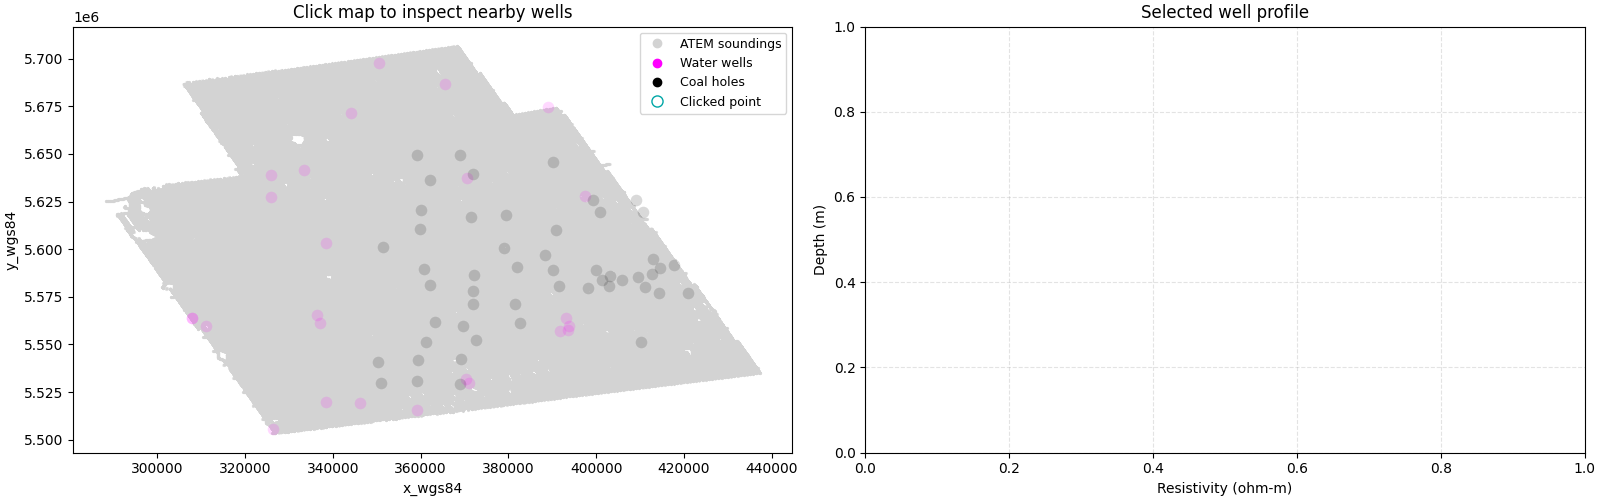

Output()

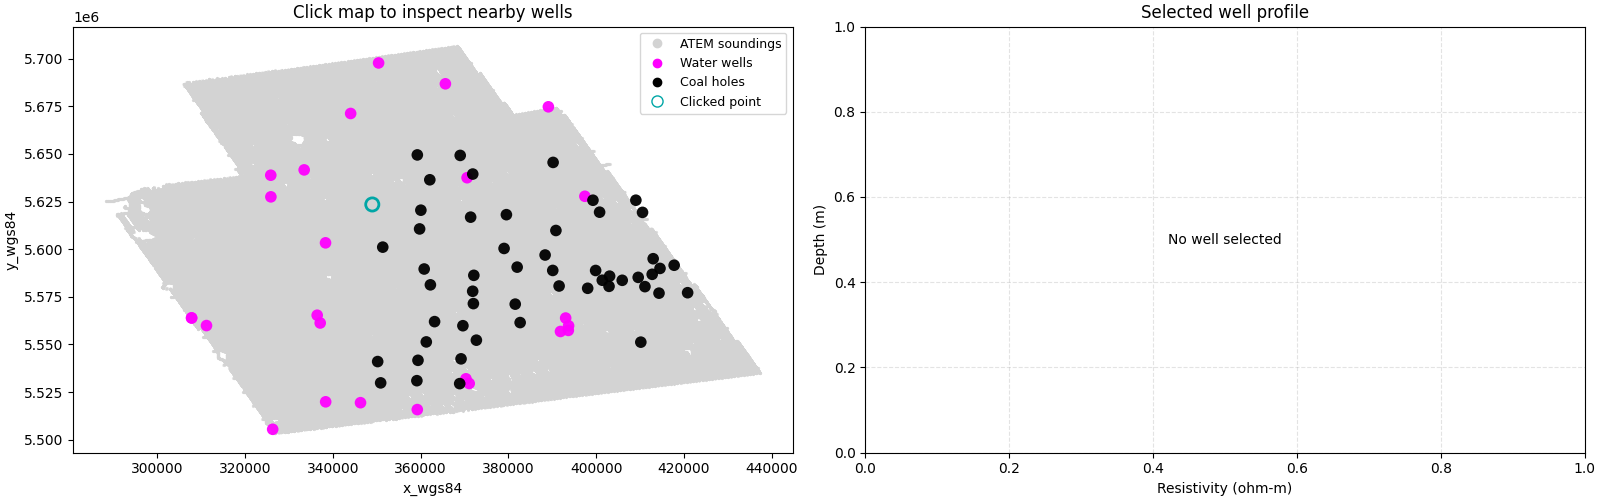

In [ ]:
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "widget")

selection_out = widgets.Output()
status_out = widgets.Output()
fig, (ax_map, ax_profile) = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

ax_map.scatter(atem_xy[:, 0], atem_xy[:, 1], s=5, c="lightgray", alpha=0.35, linewidths=0, label="ATEM soundings")
water_mask = well_df["well_type"] == "WaterWell"
coal_mask = well_df["well_type"] == "CoalHole"
water_scatter = ax_map.scatter(well_df.loc[water_mask, "x"], well_df.loc[water_mask, "y"], c="magenta", s=well_marker_size, alpha=0.15, linewidths=0, label="Water wells")
coal_scatter = ax_map.scatter(well_df.loc[coal_mask, "x"], well_df.loc[coal_mask, "y"], c="black", s=well_marker_size, alpha=0.15, linewidths=0, label="Coal holes")
click_marker = ax_map.scatter([], [], marker="o", facecolors="none", edgecolors="#00a6a6", s=click_marker_size, linewidths=2.0, zorder=8)


def update_case_style(change=None):
    case_mask = get_case_mask(case_selector.value)
    water_scatter.set_alpha(np.where(case_mask.loc[water_mask], 0.95, 0.15))
    coal_scatter.set_alpha(np.where(case_mask.loc[coal_mask], 0.95, 0.15))
    fig.canvas.draw_idle()


legend_handles = [
    Line2D([], [], marker="o", linestyle="None", markersize=6, markerfacecolor="lightgray", markeredgecolor="lightgray", label="ATEM soundings"),
    Line2D([], [], marker="o", linestyle="None", markersize=6, markerfacecolor="magenta", markeredgecolor="magenta", label="Water wells"),
    Line2D([], [], marker="o", linestyle="None", markersize=6, markerfacecolor="black", markeredgecolor="black", label="Coal holes"),
    Line2D([], [], marker="o", linestyle="None", markersize=8, markerfacecolor="none", markeredgecolor="#00a6a6", linewidth=2.0, label="Clicked point"),
]
ax_map.set(xlabel="x_wgs84", ylabel="y_wgs84", title="Click map to inspect nearby wells")
ax_map.legend(handles=legend_handles, loc="best", fontsize=9)
ax_map.grid(False)
ax_profile.set(xlabel="Resistivity (ohm-m)", ylabel="Depth (m)", title="Selected well profile")
ax_profile.grid(True, which="both", ls="--", alpha=0.35)

visible_cols = ["well_id", "well_type", "well_name", "distance_to_click_m", "has_lithology", "has_resistivity_log", "has_both"]


def render_profile_for_well(well_id):
    ax_profile.clear()
    ax_profile.set(xlabel="Resistivity (ohm-m)", ylabel="Depth (m)", title="Selected well profile")
    ax_profile.grid(True, which="both", ls="--", alpha=0.35)
    if well_id is None:
        ax_profile.text(0.5, 0.5, "No well selected", ha="center", va="center", transform=ax_profile.transAxes)
        return

    selected = well_df.loc[well_df["well_id"] == well_id].iloc[0]
    well_lith = load_well_lithology(selected["well_name"], selected["well_type"])
    near_idx = int(selected["nearest_model_idx"])
    near_dist = float(selected["nearest_model_dist_m"])
    model_profile = iter14_valid.iloc[near_idx][rho_cols].to_numpy(dtype=float)
    valid_profile = np.isfinite(model_profile) & (model_profile > 0)
    ax_profile.step(model_profile[valid_profile], depth_values[valid_profile], "-", color="blue", lw=2.0, label="Nearest inverted model")

    well_depth, well_res = load_well_las(selected["well_name"], selected["well_type"])
    if well_depth is not None and well_res is not None:
        mask = np.isfinite(well_depth) & np.isfinite(well_res) & (well_res > 0)
        if np.any(mask):
            ax_profile.plot(well_res[mask], well_depth[mask], "k-", lw=1.1, alpha=0.75, label="Well log")

    if well_lith is not None and not well_lith.empty:
        for interval in well_lith.itertuples(index=False):
            ax_profile.axhspan(interval.top_m, interval.bottom_m, xmin=0.0, xmax=0.12, facecolor=lithology_facecolor(interval.display_label), edgecolor="white", linewidth=0.4, zorder=0)
            if interval.bottom_m - interval.top_m >= 6.0:
                ax_profile.text(0.14, (interval.top_m + interval.bottom_m) / 2, interval.display_label, transform=ax_profile.get_yaxis_transform(), va="center", ha="left", fontsize=7, clip_on=True)

    depth_limit = max(depth_values.max(), 350.0, np.nanmax(well_depth) if well_depth is not None else 0, well_lith["bottom_m"].max() if well_lith is not None and not well_lith.empty else 0)
    ax_profile.set_xscale("log")
    ax_profile.set_xlim(1, 1e3)
    ax_profile.set_ylim(depth_limit * 1.03, -20)
    ax_profile.set_title(f"{selected['well_id']}\nDistance: {near_dist:.1f} m")
    ax_profile.legend(loc="upper right", fontsize=8)


def render_selection(center_x, center_y):
    nearest_dist, nearest_idx = model_tree.query([[center_x, center_y]], k=1)
    nearest_idx = int(nearest_idx[0])
    nearest_dist = float(nearest_dist[0])
    atem_row = iter14_valid.iloc[nearest_idx]
    click_marker.set_offsets(np.array([[center_x, center_y]]))
    nearby_wells, summary, by_type, nearest_well_dist = summarize_nearby_wells(center_x, center_y, search_radius_m, case_selector.value)

    with selection_out:
        selection_out.clear_output(wait=True)
        print(f"Clicked location: ({center_x:.1f}, {center_y:.1f})")
        print(f"Nearest ATEM idx = {nearest_idx} at ({atem_row['x_wgs84']:.1f}, {atem_row['y_wgs84']:.1f}), distance: {nearest_dist:.1f} m")
        print(f"Selected case: {case_selector.value}")
        if nearby_wells.empty:
            print("No wells for the selected case are within radius.")
            render_profile_for_well(None)
        else:
            display(summary)
            display(by_type)
            display(nearby_wells[visible_cols])
            render_profile_for_well(nearby_wells.iloc[0]["well_id"])
    fig.canvas.draw_idle()


def on_click(event):
    if event.inaxes == ax_map and event.xdata is not None and event.ydata is not None:
        render_selection(float(event.xdata), float(event.ydata))


case_selector.observe(update_case_style, names="value")
_ = fig.canvas.mpl_connect("button_press_event", on_click)
with status_out:
    print(f"Matplotlib backend: {plt.get_backend()}")
display(case_selector, status_out, fig.canvas, selection_out)
update_case_style()
render_selection(float(atem_xy[0, 0]), float(atem_xy[0, 1]))

In [105]:
availability_df = well_df.apply(
    lambda row: get_well_availability(row.well_id, row.well_name, row.well_type),
    axis=1,
    result_type="expand",
)

well_df[["has_lithology", "has_resistivity_log", "has_both"]] = availability_df[
    ["has_lithology", "has_resistivity_log", "has_both"]
]

# Compute 'has_neither' using vectorized boolean logic
well_df["has_neither"] = ~(well_df["has_lithology"] | well_df["has_resistivity_log"])

Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}


In [106]:
case_summary = pd.DataFrame(
    {
        "case": [
            "total_wells",
            "with_lithology_only",
            "with_resistivity_only",
            "with_both",
            "with_neither",
        ],
        "count": [
            len(well_df),
            int((well_df["has_lithology"] & ~well_df["has_resistivity_log"]).sum()),
            int((well_df["has_resistivity_log"] & ~well_df["has_lithology"]).sum()),
            int(well_df["has_both"].sum()),
            int(well_df["has_neither"].sum()),
        ],
    }
)

print("Case summary (counts by category)")
display(case_summary)

Case summary (counts by category)


,case,count
0,total_wells,77
1,with_lithology_only,19
2,with_resistivity_only,10
3,with_both,45
4,with_neither,3
